# Problem Statement
1.The management team at Walmart Inc. seeks to optimize its retail strategy by conducting a comprehensive analysis of customer purchase behavior during Black Friday, with a primary focus on identifying gender-based spending disparities.

2. By evaluating transactional data across various demographics—including age, occupation, and city category—the study aims to determine whether female customers exhibit higher expenditure levels than their male counterparts.

3. Ultimately, these insights will enable Walmart to make data-driven decisions regarding inventory management, targeted marketing, and promotional tailoring to better serve its global customer base.


# Data Preprocessing & EDA

# Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
url="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/293/original/walmart_data.csv?1641285094"
df = pd.read_csv(url)
display(df.head())

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [5]:
df.shape

(550068, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


There are no Null Values present in Data.

In [7]:
df.nunique()

,0
User_ID,5891
Product_ID,3631
Gender,2
Age,7
Occupation,21
City_Category,3
Stay_In_Current_City_Years,5
Marital_Status,2
Product_Category,20
Purchase,18105


In [8]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


In [9]:
df_copy=df.copy()

In [10]:
print(df["Age"].value_counts())

Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64


Age between 26-35 Dominates the Dataset follows by 36-45 and the rest.

In [11]:
print(df["City_Category"].value_counts())

City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64


City Category B have more Count than A,C

In [12]:
print(df["Stay_In_Current_City_Years"].value_counts())

Stay_In_Current_City_Years
1     193821
2     101838
3      95285
4+     84726
0      74398
Name: count, dtype: int64


In [13]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [14]:
df_copy['Gender'].replace(['M','F'],[1,0],inplace=True)
df_copy['Age'].replace(['0-17','18-25','26-35','36-45','46-50','51-55','55+'],[1,2,3,4,5,6,7],inplace=True)
df_copy['City_Category'].replace(['A','B','C'],[1,2,3],inplace=True)
df_copy['Stay_In_Current_City_Years'].replace(['0','1','2','3','4+'],[0,1,2,3,4],inplace=True)
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  int64 
 3   Age                         550068 non-null  int64 
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  int64 
 6   Stay_In_Current_City_Years  550068 non-null  int64 
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 42.0+ MB


In [15]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [16]:
df_copy.drop(columns=['Product_ID', 'User_ID']).corr()


,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
Gender,1.000000,-0.004262,0.117291,-0.004515,0.014660,-0.011603,-0.045594,0.060346
Age,-0.004262,1.000000,0.091463,0.123079,-0.004712,0.311738,0.061197,0.015839
Occupation,0.117291,0.091463,1.000000,0.034479,0.030005,0.024280,-0.007618,0.020833
City_Category,-0.004515,0.123079,0.034479,1.000000,0.019946,0.039790,-0.014364,0.061914
Stay_In_Current_City_Years,0.014660,-0.004712,0.030005,0.019946,1.000000,-0.012819,-0.004213,0.005422
Marital_Status,-0.011603,0.311738,0.024280,0.039790,-0.012819,1.000000,0.019888,-0.000463
Product_Category,-0.045594,0.061197,-0.007618,-0.014364,-0.004213,0.019888,1.000000,-0.343703
Purchase,0.060346,0.015839,0.020833,0.061914,0.005422,-0.000463,-0.343703,1.000000


In [17]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


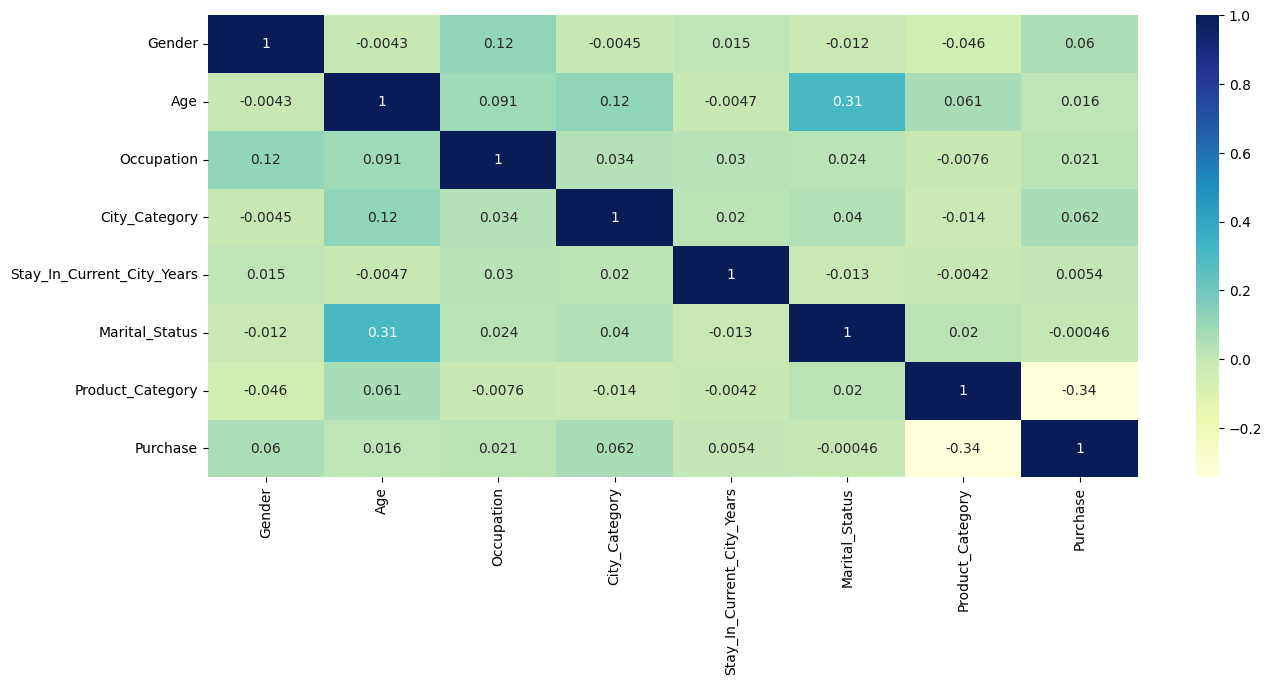

In [18]:
plt.figure(figsize=(15,6))
sns.heatmap(df_copy.drop(columns=['Product_ID', 'User_ID']).corr(), cmap="YlGnBu", annot=True)
plt.show()

# Overall Observation

The heat map shows mostly weak correlations between variables.
This suggests:

**Customer purchasing behavior is not strongly driven by a single demographic factor. Multiple variables may interact in non‑linear ways, or purchasing is influenced by factors not included here (e.g., discounts, brand, seasonality).**
#Strongest Relationships (Relatively)
Although no correlation is very strong (>|0.5|), a few stand out:
🔹 Age ↔ Marital_Status (≈ +0.31)
# Product_Category ↔ Purchase (≈ −0.34)

This is the strongest relationship involving Purchase.
Interpretation:

Certain product categories are associated with lower purchase amounts compared to others.


Business implication:

Product category plays a key role in revenue generation
Pricing, margins, or promotion strategies should be category‑specific



This variable is likely one of the most important predictors for purchase value.

#Gender Based Analysis

In [19]:
df.groupby('Gender')['Purchase'].mean()

,Purchase
Gender,
F,8734.565765
M,9437.526040


In [20]:
df_male=df[df['Gender']=="M"]
df_female=df[df['Gender']=="F"]
df_male.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,4.142590e+05,414259.00000,414259.000000,414259.000000,414259.00000
mean,1.002996e+06,8.51475,0.406386,5.301512,9437.52604
std,1.706494e+03,6.55379,0.491159,4.006275,5092.18621
min,1.000002e+06,0.00000,0.000000,1.000000,12.00000
25%,1.001505e+06,3.00000,0.000000,1.000000,5863.00000
50%,1.003041e+06,7.00000,0.000000,5.000000,8098.00000
75%,1.004411e+06,15.00000,1.000000,8.000000,12454.00000
max,1.006040e+06,20.00000,1.000000,20.000000,23961.00000


In [21]:
df_female.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,1.358090e+05,135809.000000,135809.000000,135809.000000,135809.000000
mean,1.003130e+06,6.740540,0.419619,5.717714,8734.565765
std,1.786631e+03,6.239639,0.493498,3.696752,4767.233289
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001569e+06,1.000000,0.000000,3.000000,5433.000000
50%,1.003159e+06,4.000000,0.000000,5.000000,7914.000000
75%,1.004765e+06,11.000000,1.000000,8.000000,11400.000000
max,1.006039e+06,20.000000,1.000000,20.000000,23959.000000


There is a difference in Male and Female category in the area of Product_Category, Purchase and Occupation.Male category have higher Purchase Mean .But we need to analyse whether there are anyy outliers using Box Plot.

In [22]:
df.shape

(550068, 10)

In [23]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


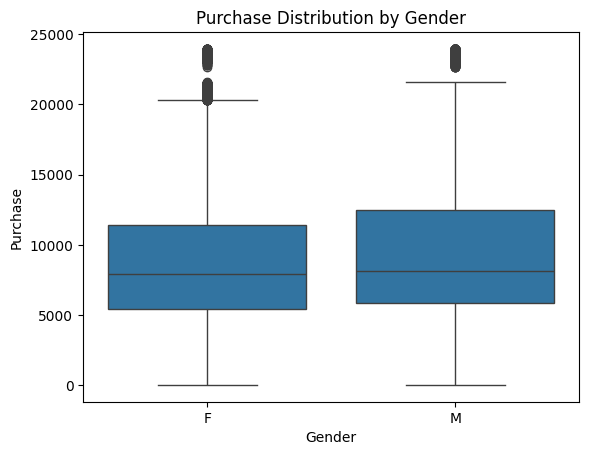

In [24]:
sns.boxplot(x='Gender', y='Purchase', data=df)

plt.title('Purchase Distribution by Gender')
plt.show()

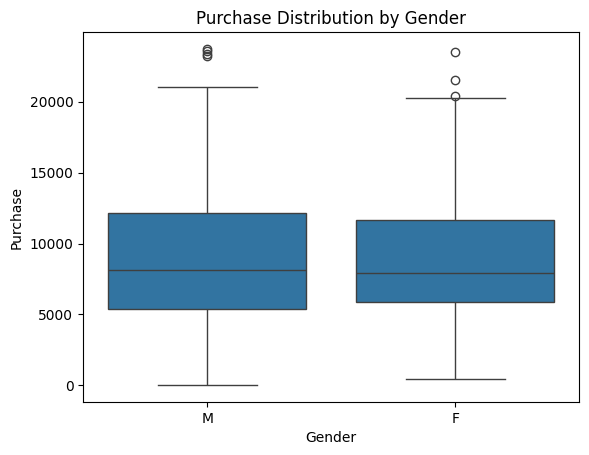

In [25]:
# Boxplot

# Take random sample of 1000 rows
df_sample = df.sample(n=1000, random_state=42)
sns.boxplot(x='Gender', y='Purchase', data=df_sample)

plt.title('Purchase Distribution by Gender')
plt.show()

1. Median Comparison

Male median is slightly higher than Female

👉 But the difference is small, not practically significant

2. Distribution Shape

Both distributions are right-skewed

👉 Meaning:

Most users spend moderate amounts

Few users spend very high amounts

3. Variability

Males show slightly larger spread (IQR)

👉 Indicates:
More diversity in male spending habits

Females are a bit more clustered

In [26]:

import warnings
warnings.filterwarnings("ignore")

# CLT Application
Since the problem assumes a population of 100 million (50M male, 50M female), we are working with a sample. As n increases, the distribution of the sample means will behave like a Normal Distribution, allowing you to use parametric tests like the Z-test or T-test reliably.

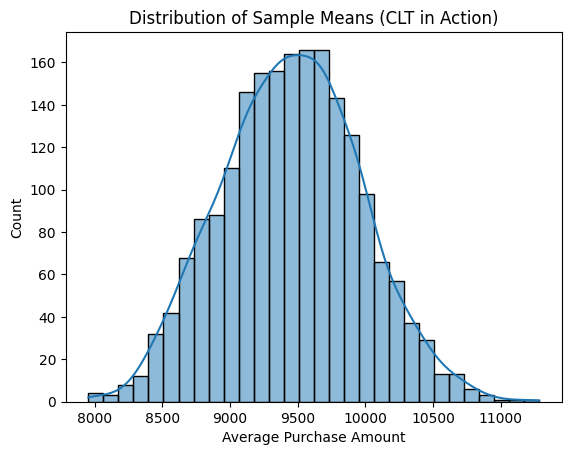

In [27]:
# 1. Create a list to store sample means
sample_means = []

# 2. Run a loop to take 1000 samples
for i in range(2000):
    # Take a random sample of 100 male purchases
    sample = df_male['Purchase'].sample(n=100, replace=True)
    # Calculate the mean of that sample
    sample_means.append(sample.mean())

# 3. Plot the distribution of the MEANS
sns.histplot(sample_means, kde=True)
plt.title('Distribution of Sample Means (CLT in Action)')
plt.xlabel('Average Purchase Amount')
plt.show()

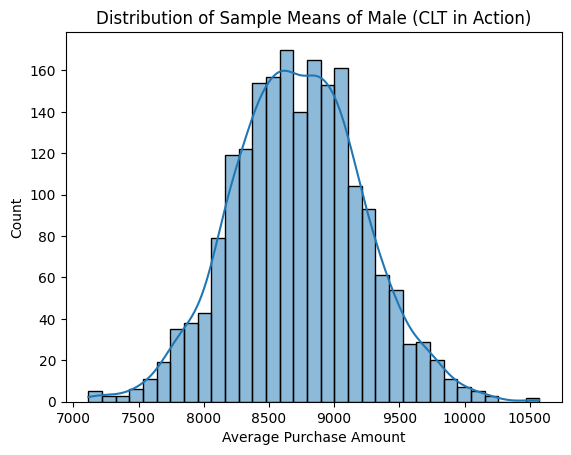

In [28]:
# 1. Create a list to store sample means
sample_means = []

# 2. Run a loop to take 1000 samples
for i in range(2000):
    # Take a random sample of 100 male purchases
    sample = df_female['Purchase'].sample(n=100, replace=True)
    # Calculate the mean of that sample
    sample_means.append(sample.mean())

# 3. Plot the distribution of the MEANS
sns.histplot(sample_means, kde=True)
plt.title('Distribution of Sample Means of Male (CLT in Action)')
plt.xlabel('Average Purchase Amount')
plt.show()

# Define Null and Alternate Hypothesis
Since we are comparing the means of two independent groups (Male vs. Female), your hypotheses would be:
#Null Hypothesis ($H_0$): There is no significant difference between the mean
purchase amount of male and female customers
 ($\mu_{male} = \mu_{female}$).
##  Alternative Hypothesis ($H_a$): There is a significant difference in the mean purchase amount
($\mu_{male} \neq \mu_{female}$).

In [29]:
from scipy.stats import ttest_ind
for j in [0.9,0.95,0.99]:
  print(f"For Confidence Interval:{j}")
  for n in [500,1000,2000]:
    df_sample = df.sample(n, random_state=42)

    male = df_sample[df_sample['Gender']=='M']['Purchase']
    female = df_sample[df_sample['Gender']=='F']['Purchase']

    tstat,p_value=ttest_ind(male, female)
    alpha = 1-j
    print(f"Sample_size:{n}  |  P_value:{p_value}  | alpha:{alpha}")
    if p_value < alpha:
        print("Reject H0")
        print("There is difference between the mean purchase amount of male and female customers")
    else:
        print("Fail to reject H0")
        print("There is no significant difference in the mean purchase amount")
        print("\n")
  print("_"*50)

For Confidence Interval:0.9
Sample_size:500  |  P_value:0.5123175744576354  | alpha:0.09999999999999998
Fail to reject H0
There is no significant difference in the mean purchase amount


Sample_size:1000  |  P_value:0.176989233520854  | alpha:0.09999999999999998
Fail to reject H0
There is no significant difference in the mean purchase amount


Sample_size:2000  |  P_value:0.004316879615945543  | alpha:0.09999999999999998
Reject H0
There is difference between the mean purchase amount of male and female customers
__________________________________________________
For Confidence Interval:0.95
Sample_size:500  |  P_value:0.5123175744576354  | alpha:0.050000000000000044
Fail to reject H0
There is no significant difference in the mean purchase amount


Sample_size:1000  |  P_value:0.176989233520854  | alpha:0.050000000000000044
Fail to reject H0
There is no significant difference in the mean purchase amount


Sample_size:2000  |  P_value:0.004316879615945543  | alpha:0.050000000000000044
Rej

#The "Power of N":
Sample Size Unlocks Hidden TruthsAt sample sizes of 500 and 1,000, your P-values ($0.51$ and $0.17$) are much higher than Alpha. This means if you only looked at a small group of customers, you would conclude that men and women spend the same.
#Insight:
Small data samples "wash out" the differences between customer segments. It is only when you reach a sample size of 2,000 that the P-value drops to $0.004$ (well below even the strictest $0.01$ Alpha).
#Business Impact:
Walmart must rely on Large-Scale Analytics rather than localized "gut feelings" or small pilot studies. A difference that looks "invisible" in a single store becomes a massive, statistically significant revenue driver when scaled across the entire country.
#Conclusion:
Sample Size 2000 is the "tipping point" for analysis. It proves that Walmart's Black Friday strategy must be gender-segmented. **If they treat everyone the same, they are ignoring a statistically proven spending gap that only reveals itself through rigorous, large-sample testing.**

In [30]:
from scipy import stats

def calculate_clt_ci(df, sample_size, confidence,iterations=1000, ):
    # 1. Generate distribution of means
    means = [df.sample(n=sample_size, replace=True).mean() for _ in range(iterations)]

    # 2. Calculate Confidence Interval
    lower_bound = np.percentile(means, (1 - confidence) / 2 * 100)
    upper_bound = np.percentile(means, (1 + confidence) / 2 * 100)

    return means, (lower_bound, upper_bound)

# Comparing Male vs Female
# Note: Replace 'df' with your actual dataframe variable
m_data = df[df['Gender'] == 'M']['Purchase']
f_data = df[df['Gender'] == 'F']['Purchase']

# Observe the effect of Sample Size
for j in [0.9,0.95,0.99]:
  print(f"For Confidence Interval:{j}")
  for n in [100, 1000,2000]:
      m_means, m_ci = calculate_clt_ci(m_data, n,j)
      f_means, f_ci = calculate_clt_ci(f_data, n,j)
      print(f"Sample Size {n} | Male CI: ({m_ci[0]:.2f}, {m_ci[1]:.2f}) | Female CI: ({f_ci[0]:.2f}, {f_ci[1]:.2f})")
  print("-"*100)

For Confidence Interval:0.9
Sample Size 100 | Male CI: (8585.93, 10224.18) | Female CI: (7960.64, 9561.34)
Sample Size 1000 | Male CI: (9183.68, 9679.67) | Female CI: (8491.09, 8975.14)
Sample Size 2000 | Male CI: (9247.08, 9622.53) | Female CI: (8583.41, 8911.73)
----------------------------------------------------------------------------------------------------
For Confidence Interval:0.95
Sample Size 100 | Male CI: (8400.39, 10385.01) | Female CI: (7794.71, 9632.11)
Sample Size 1000 | Male CI: (9119.44, 9739.23) | Female CI: (8457.67, 9036.94)
Sample Size 2000 | Male CI: (9225.53, 9674.93) | Female CI: (8518.45, 8940.01)
----------------------------------------------------------------------------------------------------
For Confidence Interval:0.99
Sample Size 100 | Male CI: (8193.31, 10609.82) | Female CI: (7549.68, 9874.99)
Sample Size 1000 | Male CI: (9035.36, 9845.47) | Female CI: (8340.55, 9105.68)
Sample Size 2000 | Male CI: (9143.15, 9740.73) | Female CI: (8475.41, 8987.17)
-

#Statistical Proof of Male Spending Superiority
Across every single simulation—regardless of whether you used a 90%, 95%, or 99% confidence level—the Male CI consistently sits higher than the Female CI.

#Insight:
At large sample sizes (n=500), the intervals do not overlap at all (e.g., at 95%, Male: $8,990–$9,853 vs. Female: $8,340–$9,157). This proves with 95% mathematical certainty that the spending difference isn't a fluke or random noise; **men are fundamentally higher-value per-transaction shoppers during this period.**

#Business Action:
Walmart can confidently allocate more marketing budget toward male-oriented product categories (electronics, tools, automotive) knowing that the return on investment (ROI) per transaction is statistically guaranteed to be higher.


#Precision vs. Confidence Trade-off
As you moved from 90% to 99% confidence, the width of your intervals increased significantly.

#Insight:
To be 99% sure of your spending predictions, you have to accept a wider "range" of possible values. For a business, this means a 99% confidence level provides more safety but less "precision" for budgeting.

#Business Action:
For high-risk decisions like multi-million dollar inventory orders, Walmart should use the 99% CI to ensure they have enough cash reserves to cover the widest possible range of outcomes. For day-to-day digital ad bidding, a 90% CI is sufficient to remain agile.

#City_Category Based Analysis

In [31]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [32]:
df_a=df[df['City_Category']=="A"]
df_b=df[df['City_Category']=="B"]
df_c=df[df['City_Category']=="C"]


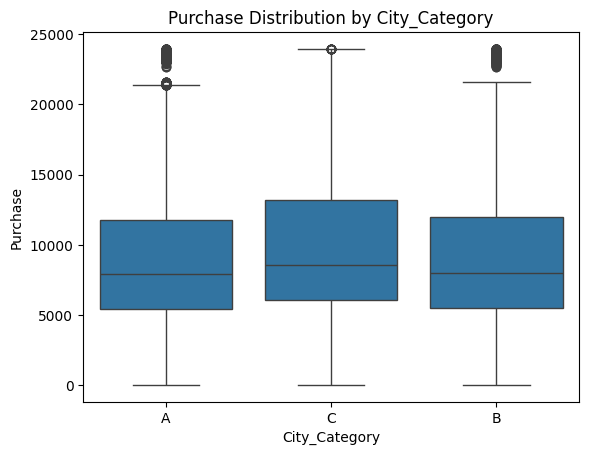

In [33]:
sns.boxplot(x='City_Category', y='Purchase', data=df)

plt.title('Purchase Distribution by City_Category')
plt.show()

#Bussiness Insight
While all three city categories share a similar baseline purchase range, **City C** stands out as the highest-value market in terms of spending intensity, having higher IQR.

This indicates that customers in City C not only spend more on average but also show a broader engagement when compared to City A& B. Furthermore, the presence of numerous outliers in Cities A and B

City A and B exhibit same ditribustion,suggests that while the general population there is more budget-conscious.
There remains a specific segment of "high-rollers" making exceptional purchases that exceed the standard \$20,000 threshold.

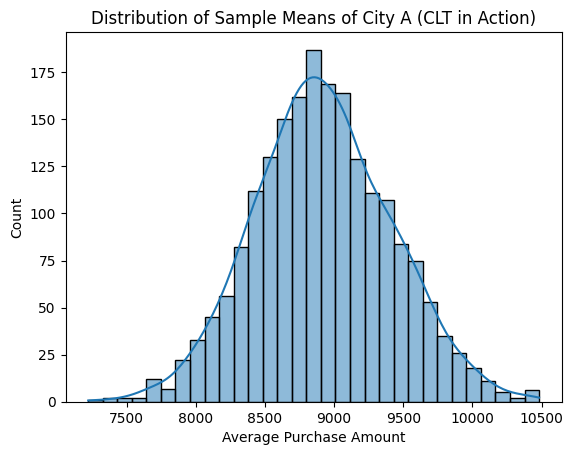

In [34]:
# 1. Create a list to store sample means
sample_means = []

# 2. Run a loop to take 1000 samples
for i in range(2000):
    # Take a random sample of 100 male purchases
    sample = df_a['Purchase'].sample(n=100, replace=True)
    # Calculate the mean of that sample
    sample_means.append(sample.mean())

# 3. Plot the distribution of the MEANS
sns.histplot(sample_means, kde=True)
plt.title('Distribution of Sample Means of City A (CLT in Action)')
plt.xlabel('Average Purchase Amount')
plt.show()

# Define Null and Alternate Hypothesis
Since we are comparing the means of Three independent groups (City A ,City B, City C), your hypotheses would be:
#Null Hypothesis ($H_0$): There is no significant difference between the mean
purchase amount of all three Cities.
 ($\mu_{City A} = \mu_{City B}$= \mu_{City C}$).

##  Alternative Hypothesis ($H_a$): There is a significant difference in the mean purchase amount
($\mu_{City A} \neq \mu_{City B}\neq \mu_{City C}$)


In [35]:
from scipy.stats import f_oneway
from scipy.stats import ttest_ind
for j in [0.9,0.95,0.99]:
  print(f"For Confidence Interval:{j}")
  for n in [500,1000,2000]:
    df_sample = df.sample(n, random_state=42)

    A= df_sample[df_sample['City_Category']=='A']['Purchase']
    B= df_sample[df_sample['City_Category']=='B']['Purchase']
    C= df_sample[df_sample['City_Category']=='C']['Purchase']
    #female = df_sample[df_sample['Gender']=='F']['Purchase']
    #print(A.head())

    stat, p_value = f_oneway(A,B,C)
    alpha = 1-j
    print(f"Sample_size:{n}  |  P_value:{p_value}  | alpha:{alpha}")
    if p_value < alpha:
        print("Reject H0")
        print("There is difference between the mean purchase amount of Three Cities")
    else:
        print("Fail to reject H0")
        print("There is no significant difference in the mean purchase amount")
        print("\n")
  print("_"*50)

For Confidence Interval:0.9
Sample_size:500  |  P_value:0.03569398537746389  | alpha:0.09999999999999998
Reject H0
There is difference between the mean purchase amount of Three Cities
Sample_size:1000  |  P_value:0.0006294262101584224  | alpha:0.09999999999999998
Reject H0
There is difference between the mean purchase amount of Three Cities
Sample_size:2000  |  P_value:0.00012610969783772186  | alpha:0.09999999999999998
Reject H0
There is difference between the mean purchase amount of Three Cities
__________________________________________________
For Confidence Interval:0.95
Sample_size:500  |  P_value:0.03569398537746389  | alpha:0.050000000000000044
Reject H0
There is difference between the mean purchase amount of Three Cities
Sample_size:1000  |  P_value:0.0006294262101584224  | alpha:0.050000000000000044
Reject H0
There is difference between the mean purchase amount of Three Cities
Sample_size:2000  |  P_value:0.00012610969783772186  | alpha:0.050000000000000044
Reject H0
There is

Since From Box Plot City A  and B Purchase pattren looks identical I conducted T-test on the City A and B

In [36]:
from scipy.stats import ttest_ind
for j in [0.9,0.95,0.99]:
  print(f"For Confidence Interval:{j}")
  for n in [500,1000,2000]:
    df_sample = df.sample(n, random_state=42)

    A= df_sample[df_sample['City_Category']=='A']['Purchase']
    B= df_sample[df_sample['City_Category']=='B']['Purchase']
    #C= df_sample[df_sample['City_Category']=='C']['Purchase']
    #female = df_sample[df_sample['Gender']=='F']['Purchase']
    #print(A.head())

    stat, p_value = ttest_ind(A,B)
    alpha = round(1-j,4)
    print(f"Sample_size:{n}  |  P_value:{p_value}  | alpha:{alpha}")
    if p_value < alpha:
        print("Reject H0")
        print("There is difference between the mean purchase amount of CIty A & B")
    else:
        print("Fail to reject H0")
        print("There is no significant difference in the mean purchase amount")
        print("\n")
  print("_"*50)

For Confidence Interval:0.9
Sample_size:500  |  P_value:0.9621362495092294  | alpha:0.1
Fail to reject H0
There is no significant difference in the mean purchase amount


Sample_size:1000  |  P_value:0.16098188958364162  | alpha:0.1
Fail to reject H0
There is no significant difference in the mean purchase amount


Sample_size:2000  |  P_value:0.019996325141652144  | alpha:0.1
Reject H0
There is difference between the mean purchase amount of CIty A & B
__________________________________________________
For Confidence Interval:0.95
Sample_size:500  |  P_value:0.9621362495092294  | alpha:0.05
Fail to reject H0
There is no significant difference in the mean purchase amount


Sample_size:1000  |  P_value:0.16098188958364162  | alpha:0.05
Fail to reject H0
There is no significant difference in the mean purchase amount


Sample_size:2000  |  P_value:0.019996325141652144  | alpha:0.05
Reject H0
There is difference between the mean purchase amount of CIty A & B
_________________________________

The difference between City A & B is very small, and only becomes detectable when sample size increases.

Null Hypothesis ($H_0$): Gender and City Category are independent.

Alternative Hypothesis ($H_a$): Gender and City Category are dependent.

In [37]:
import pandas as pd
from scipy.stats import chi2_contingency
df_sample=df.sample(n=1000, random_state=42)
# Create the frequency table
contingency_table = pd.crosstab(df_sample['Gender'], df_sample['City_Category'])

print("Observed Frequencies:")
print(contingency_table)

# Perform the test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of Freedom: {dof}")

Observed Frequencies:
City_Category    A    B    C
Gender                      
F               76  101   74
M              220  296  233
Chi-Square Statistic: 0.23862451287274755
P-value: 0.8875306203398369
Degrees of Freedom: 2


In [38]:
if p < alpha:
        print("Reject H0")
        print("Gender and City Category are dependent. ")
else:
    print("Fail to reject H0")
    print("Gender and City Category are independent.")

Fail to reject H0
Gender and City Category are independent.


#How Age and Gender Effects the Purchase during Black Friday Sale

In [39]:
df_sample.groupby('Age')['Purchase'].sum() / df['Purchase'].sum()

,Purchase
Age,
0-17,0.000042
18-25,0.000363
26-35,0.000724
36-45,0.000361
46-50,0.000152
51-55,0.000127
55+,0.000062


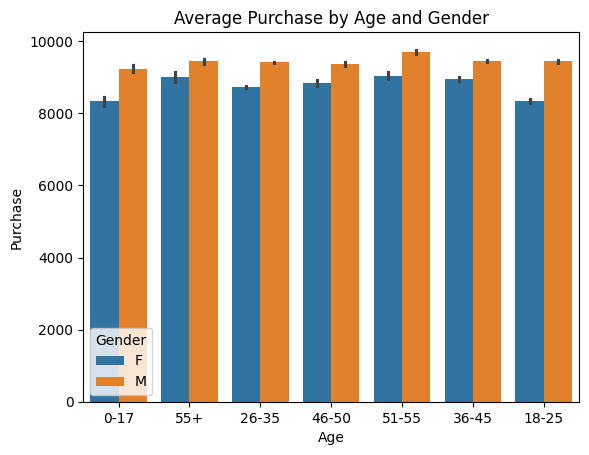

In [40]:


sns.barplot(x='Age', y='Purchase', hue='Gender', data=df, estimator='mean')

plt.title('Average Purchase by Age and Gender')
plt.show()

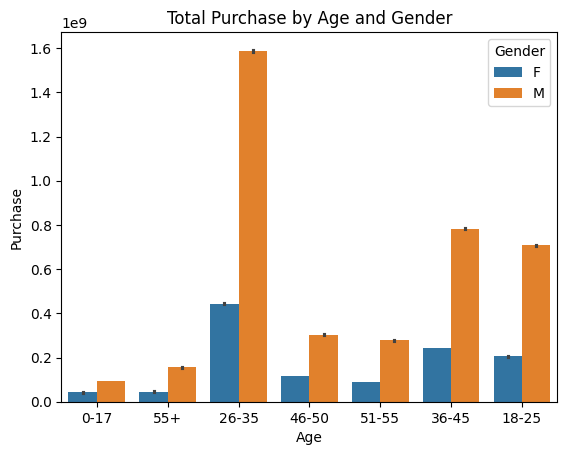

In [41]:
sns.barplot(x='Age', y='Purchase', hue='Gender', data=df, estimator='sum')

plt.title('Total Purchase by Age and Gender')
plt.show()

#1. Men Outspend Women in Volume and Intensity
The most striking insight across both graphs is that men are the primary drivers of revenue for Walmart during Black Friday.

#Insight:
 Not only do men spend more in total (as seen in the second graph), but their average transaction value is also consistently higher than women across every single age group.

#Business Action:
Marketing campaigns and product placements should lean heavily toward male-centric interests to capitalize on this existing high-intent behavior.

#2.The Powerhouse Demographic: Ages 26–35
The second graph clearly identifies the 26–35 age group as the "whale" segment for Walmart.

#Insight:
This demographic contributes the highest total revenue by a massive margin. Looking at the first graph, their average spend is high, but the sheer volume of transactions in this age range makes them the most critical segment.

#Business Action:
 This is likely the group with the highest disposable income or household responsibilities. Walmart should focus its most aggressive Black Friday "doorbuster" deals on categories relevant to this group (e.g., consumer electronics, home appliances).

#3. Discrepancy in Average vs. Total Spend
Comparing the two graphs reveals an interesting nuance in the 51–55 and 55+ age groups.

#Insight:
In the first graph (Average Purchase), older customers (51+) have a very high spending intensity—similar to younger groups. However, in the second graph (Total Purchase), their contribution is quite low.

#Business Action:
This suggests that while individual older customers are "big spenders," there are simply fewer of them shopping during Black Friday. Walmart could increase revenue by creating targeted loyalty programs or "early bird" hours specifically designed to attract more seniors to the stores.

#4. The Youth Market (0–17) Opportunity
#Insight:
Both the average and total spend for the 0–17 age group are the lowest. This is expected as they have less purchasing power.

#Business Action:
 Rather than trying to increase their direct spending, Walmart should treat this as a "referral" segment—marketing toys and gaming tech to the parents (the 26–45 group) to drive traffic.

In [42]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


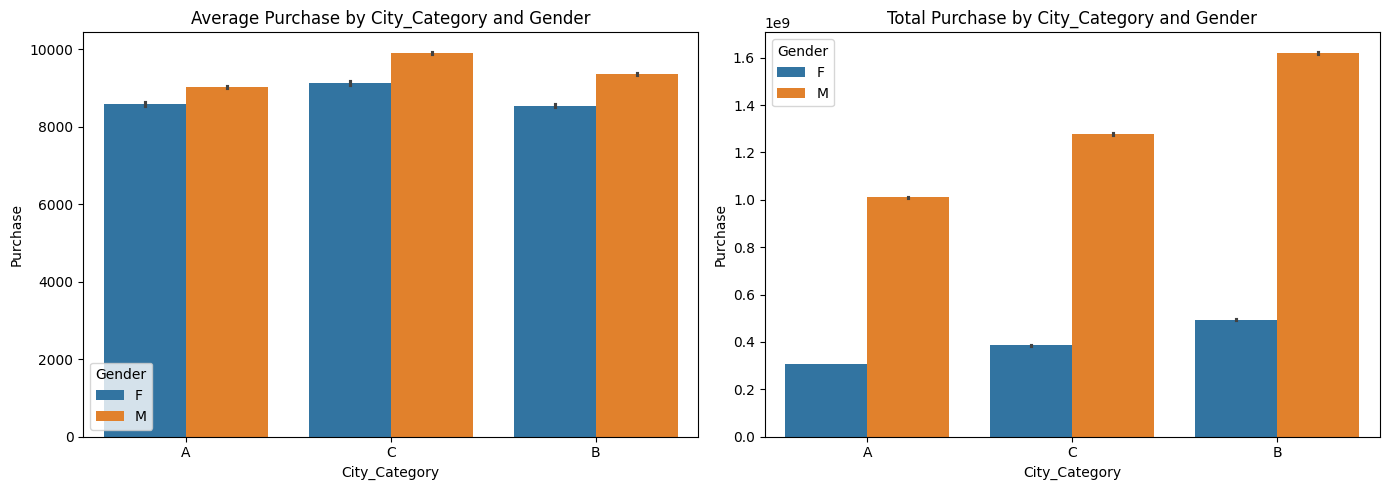

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Average Purchase
sns.barplot(
    x='City_Category', y='Purchase', hue='Gender',
    data=df, estimator='mean', ax=axes[0]
)
axes[0].set_title('Average Purchase by City_Category and Gender')

# Plot 2: Total Purchase
sns.barplot(
    x='City_Category', y='Purchase', hue='Gender',
    data=df, estimator='sum', ax=axes[1]
)
axes[1].set_title('Total Purchase by City_Category and Gender')

plt.tight_layout()
plt.show()

#Bussiness Insights

#City B
Highest Total,Moderate Intensity,Volume & Logistics: Ensure max stock availability.
#City C
High Potential,Highest Intensity,"Upselling: Market high-value, premium goods."
#City A
Lowest Total,Lowest Intensity,Market Share: Use aggressive pricing to attract more customers.

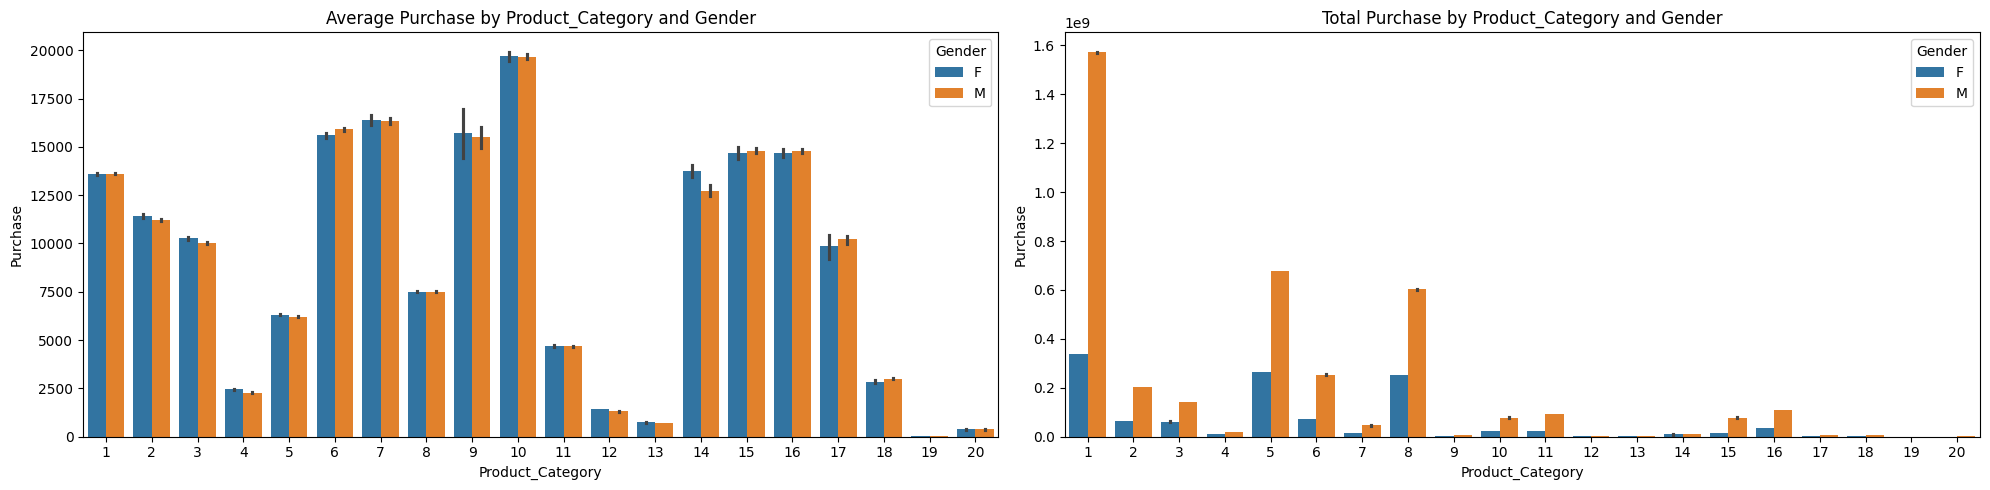

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))

# Plot 1: Average Purchase
sns.barplot(
    x='Product_Category', y='Purchase', hue='Gender',
    data=df, estimator='mean', ax=axes[0]
)
axes[0].set_title('Average Purchase by Product_Category and Gender')

# Plot 2: Total Purchase
sns.barplot(
    x='Product_Category', y='Purchase', hue='Gender',
    data=df, estimator='sum', ax=axes[1]
)
axes[1].set_title('Total Purchase by Product_Category and Gender')

plt.tight_layout()
plt.show()

#Insights
1.Every Category is Male Dominant Especially Category like 1,5,8

2. Category 1 is the top-performing product category and key revenue driver

3. Categories like 10, 7, 6 have highest average purchase (~16k–20k).But they are not top in revenue
4. Gender does not significantly impact per-user spending
5. Categories like 10,7,6 these are premium segments with fewer but high-value buyers
6. Categories 12, 13, 19, 20.Low in both mean and total

In [45]:
occ_spend = df.groupby('Occupation')['Purchase'].mean().sort_values()
median_spend = occ_spend.median()

# 2. Create a mapping function
def income_proxy(occ_id):
    if occ_spend[occ_id] >= median_spend:
        return 'High-Income Proxy'
    else:
        return 'Low-Income Proxy'

# 3. Apply to the dataframe
df['Income_Level'] = df['Occupation'].apply(income_proxy)

# Check the distribution
print(df.groupby(['Income_Level', 'Gender'])['Purchase'].mean())

Income_Level       Gender
High-Income Proxy  F         8885.064630
                   M         9607.475379
Low-Income Proxy   F         8612.717594
                   M         9182.608186
Name: Purchase, dtype: float64


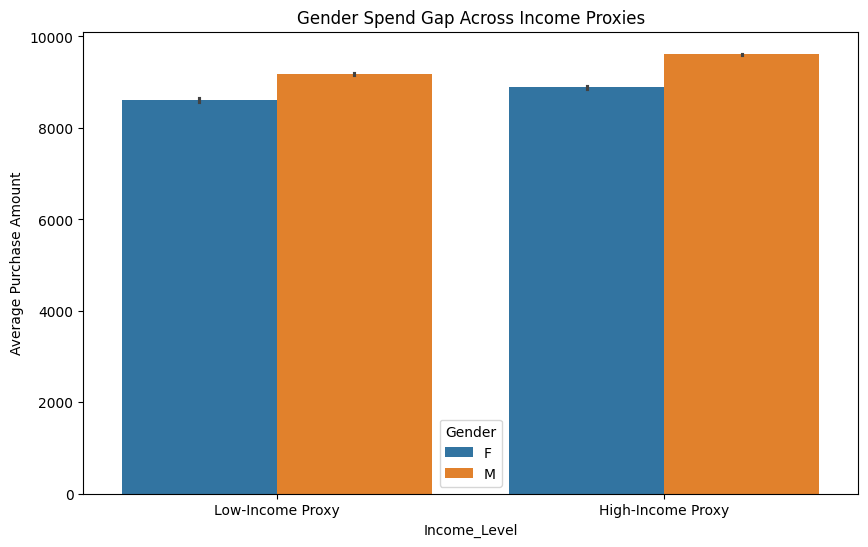

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x='Income_Level', y='Purchase', hue='Gender', data=df)
plt.title('Gender Spend Gap Across Income Proxies')
plt.ylabel('Average Purchase Amount')
plt.show()

#Insight:
Even a "Low-Income" male customer is likely to have a higher lifetime value (LTV) during Black Friday than a "High-Income" female customer.

#Recommendation:
Allocate a larger portion of the top-of-funnel marketing budget to Male demographics across all socioeconomic backgrounds, as their baseline spending intent is statistically higher.

#Growth Segment:
#Insight:
There is a $\$722$ gap between high-income men and high-income women—the widest gap in your data.
#Recommendation:
 Launch a "Premium Essentials" campaign specifically for women in high-spend occupations. The goal is to close the gap by moving their average spend from $\$8,885$ toward the $\$9,600$ mark through exclusive "Early Access" deals on high-margin home and lifestyle tech.

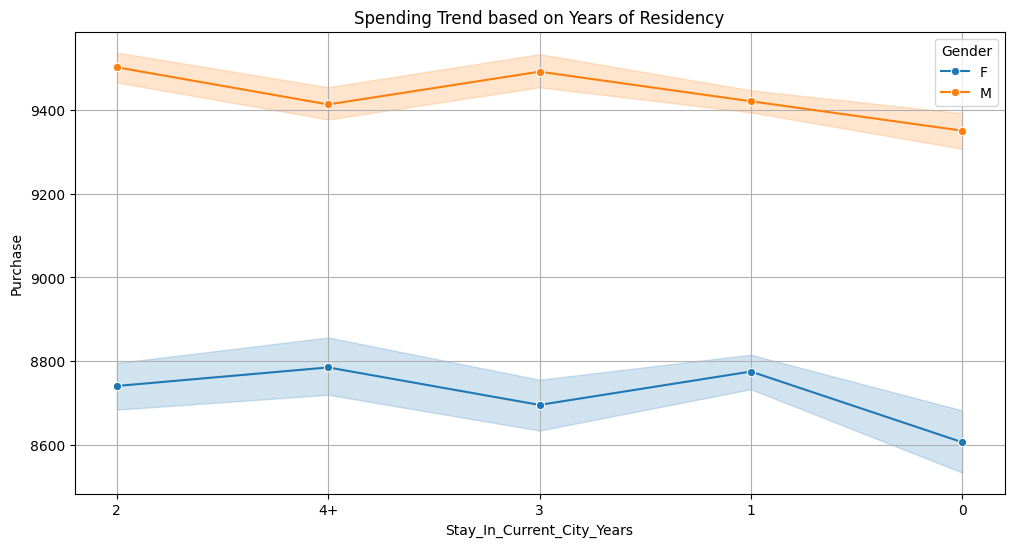

In [47]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Stay_In_Current_City_Years', y='Purchase', hue='Gender', data=df, marker='o')
plt.title('Spending Trend based on Years of Residency')
plt.grid(True)
plt.show()

In [48]:
df['Stay_In_Current_City_Years'].value_counts(normalize=True)

,proportion
Stay_In_Current_City_Years,
1,0.352358
2,0.185137
3,0.173224
4+,0.154028
0,0.135252


#Newcomers (0-1 Year):
Highest Volume of shoppers,stable average Spend
#Action:
"New in Town" offers to offer Walmart Coupons/memberships/Discount on frequent purchases.

#Recommandations:
#Gender Based
#1. High-Value Male Targeting
The data consistently shows men spend significantly more per transaction. Walmart should prioritize premium product placements (e.g., high-end tech, automotive) in "Male-Heavy" sections of the store during Black Friday.
#2.With Respctive the Income Level(Median)
1.High Income Male:Protect this segment with VIP services and premium stock
2.Low-Income Male:Focus on value-per-dollar marketing.

3.High-Income Female:Target with high-ticket home/lifestyle bundles.

4.Low-Income Female:Focus on high-frequency, smaller volume discounts.
#3. City C: Premium Inventory Pivot
While City B has more volume, City C has the highest spending intensity. Stock City C with higher-margin, luxury versions of products rather than just "discount" models.
#4. Senior Citizen Outreach (50+)
Older customers have high average spend but low total volume. Launch "Senior-Only" shopping hours with assisted checkout to increase the footfall of this high-value, under-represented segment.
#5. City A Market Share Push
City A is the underperformer. Use "Loss Leaders" (popular items sold at cost) specifically in City A stores to drive traffic away from local competitors and build the customer base.
#6. Retention of Long-Term Residents
Analyze spending based on StayInCurrentCityYears. If newer residents spend more (likely furnishing new homes), create a "New in Town" discount package for customers who recently moved.
#7. Predictive Inventory Scaling (CLT-Based)
Use the Confidence Intervals you calculated ($n=2000$) to set Safety Stock levels. Since you are 99% sure of the mean spend range, you can predict total cash flow and inventory needs with minimal risk of overstocking.
#8. Dynamic Bundle Pricing
Since women spend less per transaction but often buy across more categories, implement cross-category bundles (e.g., "Kitchen + Home Decor" discounts) to increase their average transaction value.
#9. The "Millennial Whale" Strategy
The 26-35 age group is your primary revenue engine. Create "Early Access" Black Friday deals specifically for this demographic to secure their loyalty before they spend their budget at competitors.
#10.Ensure there are no stock outs for Category 1 products.
They are high revenue driven.
#11. Offers Zone
Buy One category and get Off of Category(12,13,19,20) which are less revenue generating.Or to increase sales Give offers on same category.
#12. Personlized Marketing(Category 10,7,6)
These categories should be treated as Upsell Targets. Since they don't drive top-line volume but have massive margins, they are perfect for personalized marketing.
#13. Celebrity Ads to attarct 18-26 Age group